# Wine Quality Prediction
**Oasis Infobyte Internship · Data Analytics · Level 2 — Task 2**<br>
**Author:** Ojewumi Asaph Felix

**Objective:** predict the quality of a wine from its physicochemical properties (acidity, sugar, alcohol…), and compare three classifiers: **Random Forest, Stochastic Gradient Descent (SGD) and Support Vector Classifier (SVC)**.

**Dataset:** *Wine Quality* (UCI Machine Learning Repository, Cortez et al., 2009) — Portuguese *Vinho Verde* wines: **1,599 red and 4,898 white**, 11 lab measurements each, and a quality score from 0 to 10 given by wine experts.

> **Key results**
> - **1,177 duplicated wines** were removed: keeping them makes the test scores look better than they really are (data leakage: +3 points of accuracy).
> - Quality is turned into a business question: **is the wine "good" (score ≥ 7)?** Only **19 %** of wines are good, so the models are evaluated on the **F1-score of the "good" class**, not only on accuracy.
> - **Random Forest is the best model** (accuracy 81 %, F1 "good" = 0.61), ahead of SVC (0.55) and SGD (0.52).
> - **Alcohol** is by far the most important feature, followed by **density**, then **chlorides** and **volatile acidity**.

**Contents**
1. Data loading and inspection
2. Exploratory data analysis
3. Class imbalance
4. Feature engineering: from scores to classes
5. Stratified train / test split
6. Training the three classifiers
7. Evaluation
8. Feature importance
9. Model comparison
10. Conclusion

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:,.3f}".format)

BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#b9b8b3", "#0b0b0b", "#52514e"
RED_WINE, WHITE_WINE = "#a3303a", "#d9b44a"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfcecb", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12.5, "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

## 1. Data Loading and Inspection
The dataset comes as two files (red and white wines). We combine them and keep the wine type as a feature (`is_red`).

In [2]:
red = pd.read_csv("data/winequality-red.csv", sep=";").assign(is_red=1)
white = pd.read_csv("data/winequality-white.csv", sep=";").assign(is_red=0)
raw = pd.concat([red, white], ignore_index=True)
print("Red wines:", len(red), "· White wines:", len(white), "· Total:", raw.shape)
raw.head()

Red wines: 1599 · White wines: 4898 · Total: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,1
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5,1
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5,1
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6,1
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,1


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
print("Missing values :", raw.isna().sum().sum())
print("Duplicated rows:", raw.duplicated().sum(),
      f"(red: {red.duplicated().sum()}, white: {white.duplicated().sum()})")

df = raw.drop_duplicates().reset_index(drop=True)
print("Wines after removing duplicates:", len(df))

Missing values : 0
Duplicated rows: 1177 (red: 240, white: 937)
Wines after removing duplicates: 5320


**Observations:**
- 12 numerical columns, **no missing values**.
- **1,177 rows (18 %) are exact duplicates** — same 11 measurements and same score. If we keep them, the same wine can end up in both the training set and the test set: the model is then tested on wines it has already seen, and the scores are **artificially high** (we measure this effect in section 9). We keep only one copy of each wine: **5,320 unique wines**.

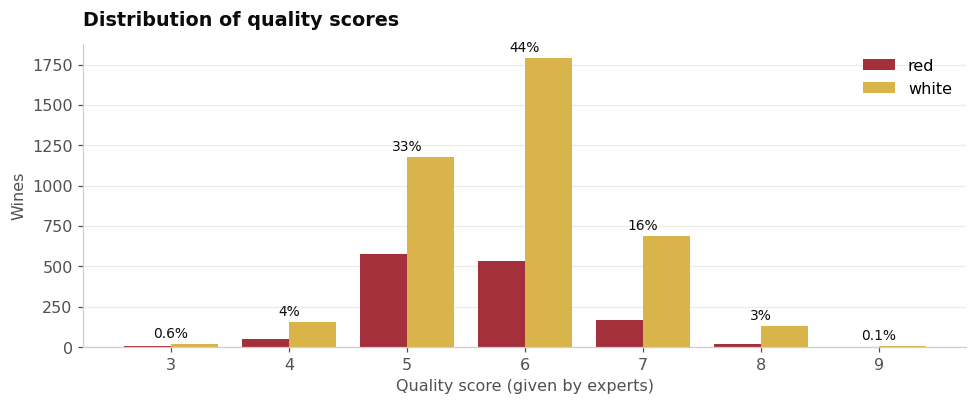

In [5]:
scores = df["quality"].value_counts().sort_index()
by_type = pd.crosstab(df["quality"], df["is_red"].map({1: "red", 0: "white"}))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(by_type))
ax.bar(x - 0.2, by_type["red"], width=0.4, color=RED_WINE, label="red")
ax.bar(x + 0.2, by_type["white"], width=0.4, color=WHITE_WINE, label="white")
ax.set_xticks(x, by_type.index)
for xi, v in zip(x, scores.values):
    ax.text(xi, max(by_type.loc[scores.index[xi]]) + 40, f"{v / scores.sum():.0%}" if v / scores.sum() >= 0.01 else f"{v / scores.sum():.1%}", ha="center", color=INK, fontsize=9)
ax.set_xlabel("Quality score (given by experts)")
ax.set_ylabel("Wines")
ax.set_title("Distribution of quality scores")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/quality_distribution.png")
plt.show()

**Observation:** scores only range from **3 to 9**, and **77 % of the wines are rated 5 or 6** ("average"). Very bad (3–4) and excellent (8–9) wines are rare.

## 2. Exploratory Data Analysis
### 2.1 Distribution of every chemical feature
Each histogram compares **good wines (score ≥ 7)** with the others. The more the two shapes differ, the more useful the feature is to recognise a good wine.

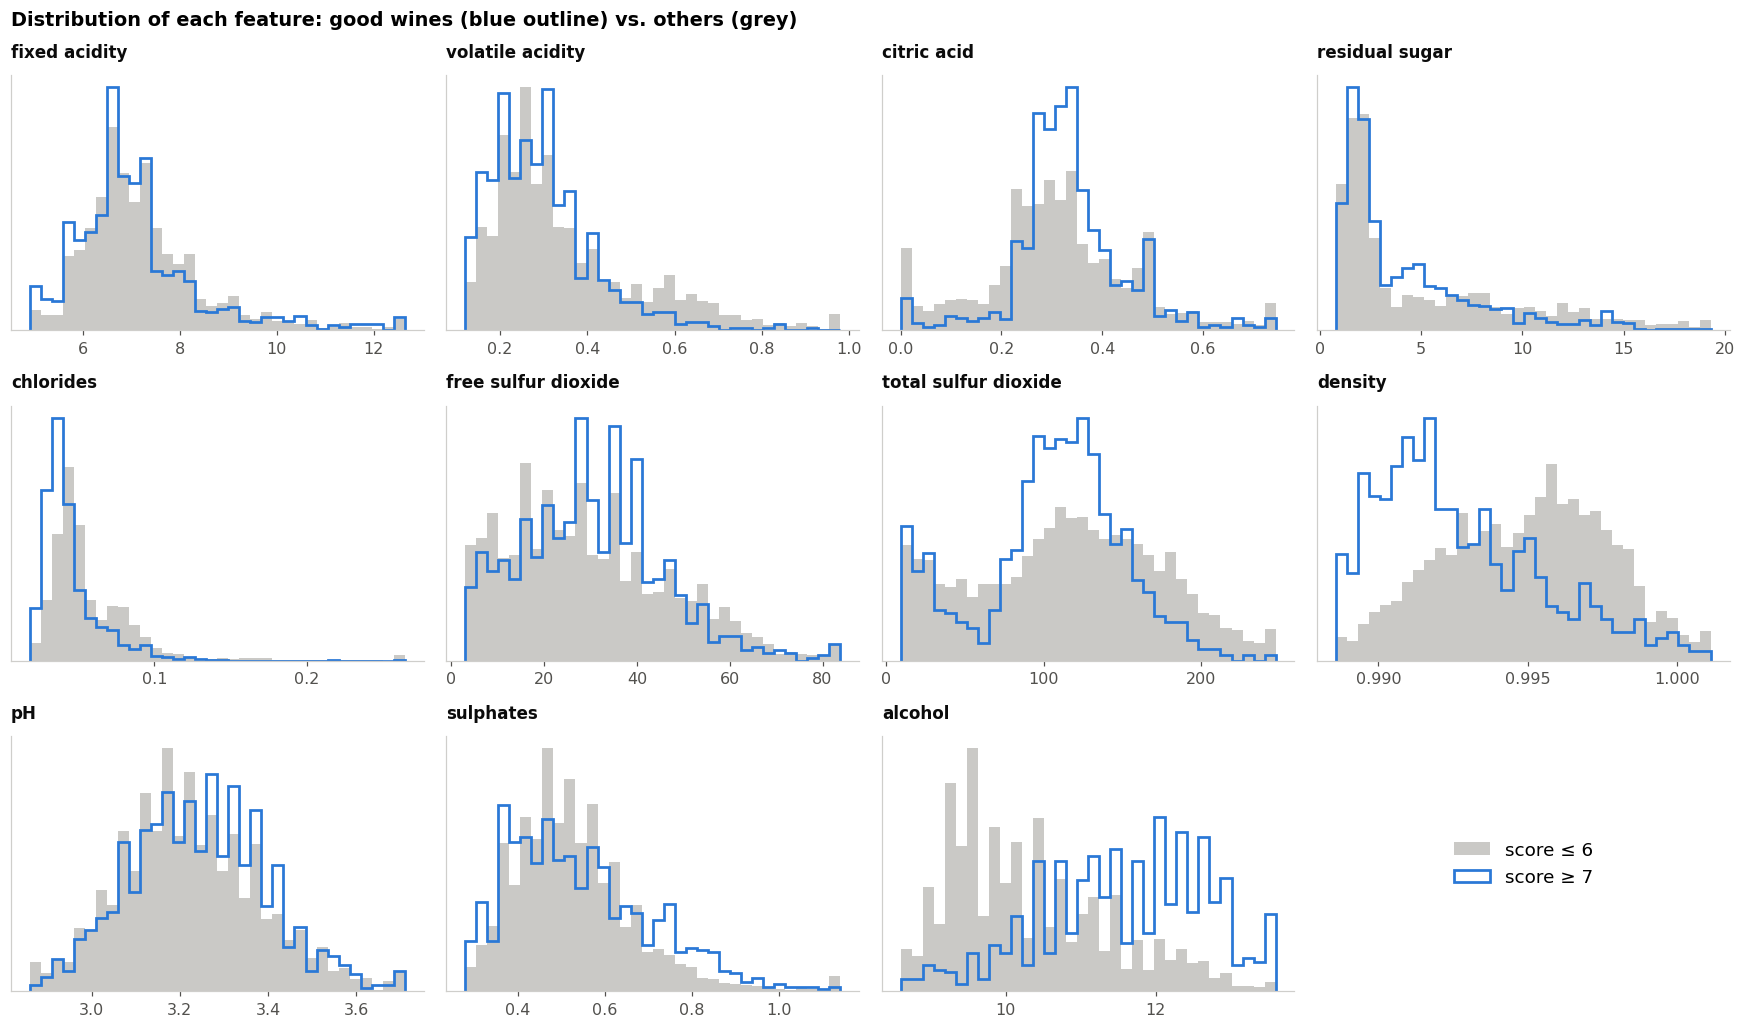

In [6]:
FEATURES = [c for c in df.columns if c not in ["quality", "is_red"]]
good = df["quality"] >= 7

fig, axes = plt.subplots(3, 4, figsize=(16, 9.5))
for ax, col in zip(axes.flat, FEATURES):
    lo, hi = df[col].quantile([0.005, 0.995])
    bins = np.linspace(lo, hi, 35)
    ax.hist(df.loc[~good, col].clip(lo, hi), bins=bins, density=True, color=GREY, alpha=0.75, label="score ≤ 6")
    ax.hist(df.loc[good, col].clip(lo, hi), bins=bins, density=True, histtype="step", color=BLUE, lw=1.8, label="score ≥ 7")
    ax.set_title(col, fontsize=11)
    ax.locator_params(axis="x", nbins=5)
    ax.set_yticks([])
    ax.grid(False)
axes.flat[-1].axis("off")
axes.flat[-1].legend(*axes.flat[0].get_legend_handles_labels(), loc="center", frameon=False, fontsize=12)
plt.suptitle("Distribution of each feature: good wines (blue outline) vs. others (grey)", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("images/feature_distributions.png")
plt.show()

**Observations:**
- **Alcohol** shows the clearest difference: good wines are clearly **stronger in alcohol**.
- Good wines also tend to have **lower density**, **lower volatile acidity** (the acetic acid responsible for a vinegar taste) and **fewer chlorides** (salt).
- Other features (pH, sulphates, free sulfur dioxide…) look almost the same in both groups.
- Several features (residual sugar, chlorides, sulfur dioxide) are **right-skewed** with some extreme values; tree-based models are not sensitive to this, while SGD and SVC need **standardised** features.

### 2.2 Correlation heatmap

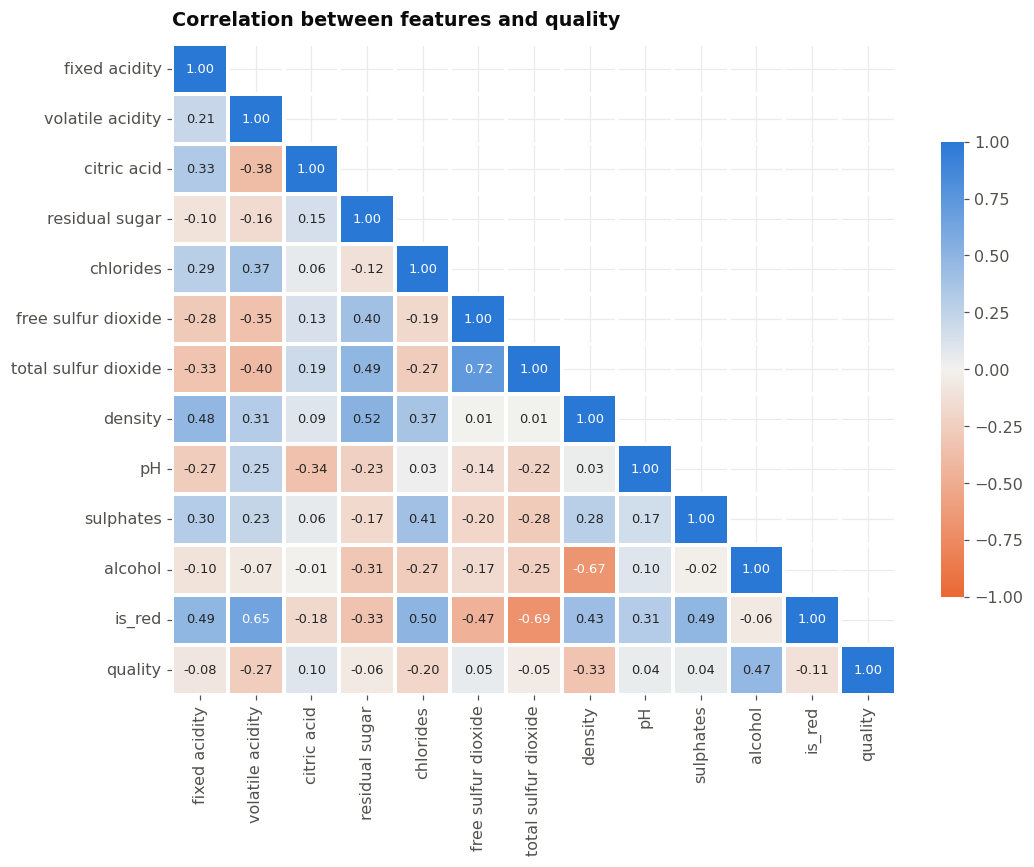

,density,volatile acidity,chlorides,is_red,fixed acidity,residual sugar,total sulfur dioxide,pH,sulphates,free sulfur dioxide,citric acid,alcohol
correlation with quality,-0.326,-0.265,-0.202,-0.115,-0.080,-0.057,-0.050,0.040,0.042,0.054,0.098,0.469


In [7]:
corr = df[FEATURES + ["is_red", "quality"]].corr()
diverging = LinearSegmentedColormap.from_list("div", [ORANGE, "#f2f1ee", BLUE])
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=diverging, vmin=-1, vmax=1, center=0,
            linewidths=1.5, linecolor="white", cbar_kws={"shrink": 0.7}, annot_kws={"fontsize": 8.5}, ax=ax)
ax.set_title("Correlation between features and quality")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

corr["quality"].drop("quality").sort_values().to_frame("correlation with quality").T

**Observations:**
- **Alcohol (+0.47)** is the feature most correlated with quality, followed by **density (−0.33)**, **volatile acidity (−0.27)** and **chlorides (−0.20)**.
- **Density and alcohol are strongly linked (−0.67)**: alcohol is lighter than water, so strong wines are less dense. Part of the "density" effect is therefore an alcohol effect.
- No single feature is very strongly correlated with quality: predicting it requires **combining several features**, which is a job for machine learning.

## 3. Class Imbalance
Scores 5 and 6 represent 77 % of the data, while scores 3, 8 and 9 have only 30, 148 and 5 wines. A model trained on the raw scores would almost never predict a 3 or a 9, simply because it has seen too few of them, and **accuracy would hide this problem** (always answering "6" is already right 44 % of the time).

We handle the imbalance in two ways:
1. **Group the scores into meaningful classes** (section 4).
2. Train the models with **`class_weight="balanced"`**, which gives more weight to errors on the rare class, and use a **stratified** split.

## 4. Feature Engineering: from Scores to Classes
Two options were considered:

| Option | Classes | Business question |
|---|---|---|
| 3 classes | low (3–5) / medium (6) / high (7–9) | "Which quality level is this wine?" |
| **Binary** | **good (≥ 7) / not good (≤ 6)** | **"Is this a premium wine worth promoting?"** |

We test the 3-class option quickly with a Random Forest:

In [8]:
three = pd.cut(df["quality"], bins=[0, 5, 6, 10], labels=["low", "medium", "high"])
Xa, Xb, ya, yb = train_test_split(df.drop(columns="quality"), three, test_size=0.2, stratify=three, random_state=42)
rf3 = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1).fit(Xa, ya)
print(f"3 classes: accuracy = {accuracy_score(yb, rf3.predict(Xb)):.1%}")
print(classification_report(yb, rf3.predict(Xb), digits=3))

3 classes: accuracy = 64.1%
              precision    recall  f1-score   support

        high      0.558     0.574     0.566       202
         low      0.708     0.725     0.716       397
      medium      0.619     0.598     0.608       465

    accuracy                          0.641      1064
   macro avg      0.628     0.633     0.630      1064
weighted avg      0.640     0.641     0.641      1064



**Decision: binary classification (good ≥ 7 vs. not good).**
- With 3 classes, the model reaches only **≈ 64 % accuracy**, mostly because **scores 5 and 6 are very hard to separate**: the experts' own scores between 5 and 6 are subjective, and the chemical measurements of these wines overlap a lot (section 2).
- The binary question is **clearer and more useful**: a wine producer or a shop wants to know which wines are **premium**. The threshold of 7 is the usual definition of a "good" wine for this dataset.
- The cost: the "good" class is a **minority (19 %)**, which we handle with balanced class weights and an F1-based evaluation.

In [9]:
df["label"] = np.where(df["quality"] >= 7, "good", "not good")
X = df.drop(columns=["quality", "label"])
y = (df["label"] == "good").astype(int)          # 1 = good
y.value_counts().rename({0: "not good (0)", 1: "good (1)"}).to_frame("wines").assign(share=lambda t: t["wines"] / t["wines"].sum())

,wines,share
label,,
not good (0),4311,0.810
good (1),1009,0.190


## 5. Stratified Train / Test Split (80 / 20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {len(X_train)} wines ({y_train.mean():.1%} good)")
print(f"Test : {len(X_test)} wines ({y_test.mean():.1%} good)")

Train: 4256 wines (19.0% good)
Test : 1064 wines (19.0% good)


Thanks to **stratification**, the share of good wines is the same (19 %) in both sets.

## 6. Training the Three Classifiers
- **Random Forest**: hundreds of decision trees vote together; captures non-linear effects and needs no scaling.
- **SGD (Stochastic Gradient Descent)**: a linear model (logistic loss) trained step by step; very fast, but only draws straight boundaries.
- **SVC (Support Vector Classifier)** with RBF kernel: finds the widest possible margin between classes, can draw curved boundaries.

SGD and SVC are placed in a pipeline with **`StandardScaler`**. The main hyper-parameters of each model are tuned with **5-fold cross-validation on the training set**, maximising the F1-score of the "good" class. The test set is used only once, at the end.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
searches = {
    "Random Forest": GridSearchCV(
        Pipeline([("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1))]),
        {"model__min_samples_leaf": [1, 3, 5], "model__max_features": ["sqrt", 0.5]}, cv=cv, scoring="f1", n_jobs=-1),
    "SGD": GridSearchCV(
        Pipeline([("scale", StandardScaler()),
                  ("model", SGDClassifier(loss="log_loss", class_weight="balanced", max_iter=2000, random_state=42))]),
        {"model__alpha": [1e-4, 1e-3, 1e-2], "model__penalty": ["l2", "elasticnet"]}, cv=cv, scoring="f1", n_jobs=-1),
    "SVC": GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("model", SVC(class_weight="balanced", random_state=42))]),
        {"model__C": [0.3, 1, 3, 10], "model__gamma": ["scale", 0.3]}, cv=cv, scoring="f1", n_jobs=-1),
}
models, predictions = {}, {}
for name, search in searches.items():
    search.fit(X_train, y_train)
    models[name] = search.best_estimator_
    predictions[name] = search.predict(X_test)
    params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print(f"{name:<14} best parameters: {params}  ·  cross-validated F1 = {search.best_score_:.3f}")

Random Forest  best parameters: {'max_features': 'sqrt', 'min_samples_leaf': 5}  ·  cross-validated F1 = 0.564
SGD            best parameters: {'alpha': 0.001, 'penalty': 'elasticnet'}  ·  cross-validated F1 = 0.540
SVC            best parameters: {'C': 1, 'gamma': 'scale'}  ·  cross-validated F1 = 0.545


## 7. Evaluation

In [12]:
for name, pred in predictions.items():
    print(f"==== {name} ====  accuracy = {accuracy_score(y_test, pred):.3f}")
    print(classification_report(y_test, pred, target_names=["not good", "good"], digits=3))

==== Random Forest ====  accuracy = 0.813
              precision    recall  f1-score   support

    not good      0.938     0.824     0.877       862
        good      0.505     0.767     0.609       202

    accuracy                          0.813      1064
   macro avg      0.721     0.795     0.743      1064
weighted avg      0.856     0.813     0.826      1064

==== SGD ====  accuracy = 0.726
              precision    recall  f1-score   support

    not good      0.934     0.711     0.808       862
        good      0.390     0.787     0.521       202

    accuracy                          0.726      1064
   macro avg      0.662     0.749     0.664      1064
weighted avg      0.831     0.726     0.753      1064

==== SVC ====  accuracy = 0.737
              precision    recall  f1-score   support

    not good      0.948     0.715     0.815       862
        good      0.406     0.832     0.545       202

    accuracy                          0.737      1064
   macro avg      0.67

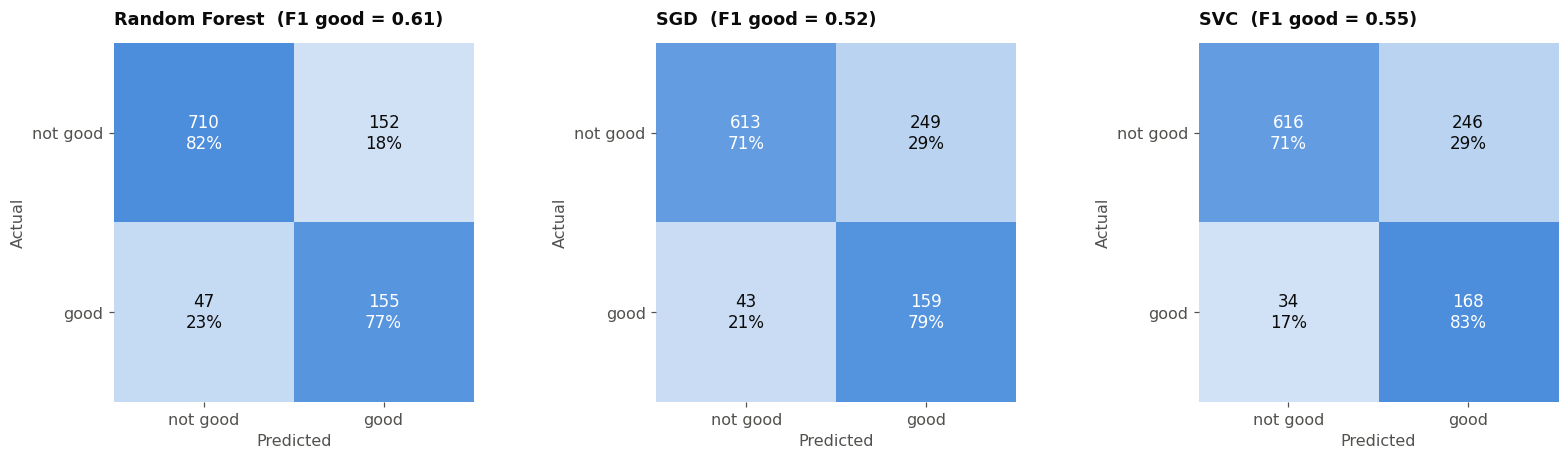

In [13]:
cmap = LinearSegmentedColormap.from_list("blues", ["#f4f8fd", BLUE])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            share = cm[i, j] / cm[i].sum()
            ax.text(j, i, f"{cm[i, j]}\n{share:.0%}", ha="center", va="center",
                    color="white" if share > 0.55 else INK, fontsize=11)
    ax.set_xticks([0, 1], ["not good", "good"]); ax.set_yticks([0, 1], ["not good", "good"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{name}  (F1 good = {f1_score(y_test, pred):.2f})", fontsize=11.5)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.savefig("images/confusion_matrices.png")
plt.show()

**Observations:**
- **Random Forest** gives the best balance: it finds about **3 good wines out of 4** (recall 0.77), and about **half** of the wines it labels "good" really are good (precision 0.51).
- **SGD and SVC** find slightly more good wines (recall 0.79 and 0.83), but raise **many more false alarms**: only 4 out of 10 wines they call "good" really are (precision ≈ 0.4). Their F1 is therefore lower.
- All models are very good at recognising "not good" wines (≈ 0.9 precision), which is expected since they are the majority.

## 8. Feature Importance (Random Forest)

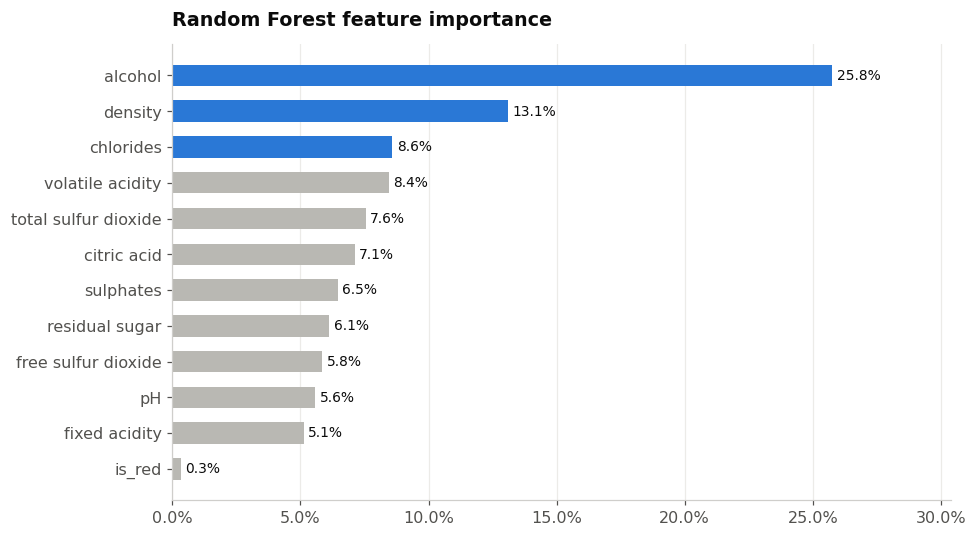

In [14]:
rf = models["Random Forest"].named_steps["model"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [BLUE if v >= importance.nlargest(3).min() else GREY for v in importance.values]
bars = ax.barh(importance.index, importance.values, color=colors, height=0.6)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in importance.values], padding=3, color=INK, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xlim(0, importance.max() * 1.18)
ax.set_title("Random Forest feature importance")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()

**Observations:**
- **Alcohol** is by far the most important feature (26 %), followed by **density** (13 %), then **chlorides** and **volatile acidity** (≈ 8.5 % each) — the same features that stood out in the EDA.
- The **wine type** (`is_red`) is the least important feature: the chemical measurements already contain the information that matters.
- For a producer, this suggests where to act: **higher alcohol (riper grapes), low volatile acidity (good fermentation hygiene)** are associated with better scores.

## 9. Model Comparison

In [15]:
comparison = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, p),
        "Precision (good)": precision_score(y_test, p),
        "Recall (good)": recall_score(y_test, p),
        "F1 (good)": f1_score(y_test, p),
        "Macro F1": f1_score(y_test, p, average="macro"),
    } for name, p in predictions.items()
}).T.sort_values("F1 (good)", ascending=False)
comparison

,Accuracy,Precision (good),Recall (good),F1 (good),Macro F1
Random Forest,0.813,0.505,0.767,0.609,0.743
SVC,0.737,0.406,0.832,0.545,0.680
SGD,0.726,0.390,0.787,0.521,0.664


**Why removing duplicates mattered.** The same Random Forest trained and tested on the data **with duplicates**:

In [16]:
Xd, yd = raw.drop(columns="quality"), (raw["quality"] >= 7).astype(int)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, stratify=yd, random_state=42)
leaky = RandomForestClassifier(n_estimators=300, class_weight="balanced", min_samples_leaf=5, random_state=42, n_jobs=-1)
leaky_pred = leaky.fit(Xd_train, yd_train).predict(Xd_test)
in_train = Xd_test.merge(Xd_train.drop_duplicates(), how="inner").shape[0]
print(f"Test wines that also appear in the training set: {in_train} of {len(Xd_test)}")
pd.DataFrame({"with duplicates (leakage)": [accuracy_score(yd_test, leaky_pred), f1_score(yd_test, leaky_pred)],
              "without duplicates (honest)": [comparison.loc["Random Forest", "Accuracy"], comparison.loc["Random Forest", "F1 (good)"]]},
             index=["Accuracy", "F1 (good)"])

Test wines that also appear in the training set: 396 of 1300


,with duplicates (leakage),without duplicates (honest)
Accuracy,0.841,0.813
F1 (good),0.654,0.609


With duplicates, **396 of the 1,300 test wines were already seen during training**, and the scores look better than they really are (+3 points of accuracy, +0.05 F1). The honest numbers are the ones **without duplicates**.

## 10. Conclusion
**Most suitable model for deployment: Random Forest.**
- **Best F1 on good wines (≈ 0.61) and best accuracy (≈ 81 %)** of the three models, with far fewer false alarms than SGD and SVC.
- Captures **non-linear effects** (e.g. alcohol matters differently depending on acidity) without scaling.
- **Explainable** through feature importance, and fast to predict.
- SGD is the fastest to train but, being linear, is too simple for this problem; SVC is close to SGD here and much slower to train.

**Practical use:** a producer or a wine shop can use the model as a **first screening tool**: wines predicted "good" are sent in priority to the tasting panel. Lab measurements are cheap and fast compared with a panel of experts.

**Limitations:**
- Quality is a **subjective** expert score, and only 11 chemical measurements are available (no grape variety, price, region or vintage).
- F1 ≈ 0.6 means the model is a **helper, not a replacement** for tasting.
- Data from one region (*Vinho Verde*, Portugal).